In [8]:
import sys
sys.path.append('..')
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup
from CoupledModel import CoupledModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
lag     = 100
horizon = 40

model_configs = {
    'AMOC':    {'target_col': 'AMOC',    'feature_cols': ['SFWF', 'PD_200m']},
    'SFWF':    {'target_col': 'SFWF',    'feature_cols': ['AMOC', 'PD_200m']},
    'PD_200m': {'target_col': 'PD_200m', 'feature_cols': ['SFWF', 'AMOC']},
}


params = {
    'n_features': 2,
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': torch.nn.MSELoss()
}


X = pd.read_csv('/Users/isakrockstrom/Desktop/Ocean/AML_proj/data/CESMDataset_Try.csv')
train_cut_1 = 5000
train_cut_2 = 11000
batch_size  = 128
n_epochs    = 20
device      = 'cpu'

trained_models = {}

for name, config in model_configs.items():
    X_train_lag, y_train_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(
        X, config['target_col'], config['feature_cols'],
        train_cut_1, train_cut_2, lag, horizon
    )
    X_train_t, y_train_t, train_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(
        batch_size, X_train_lag, y_train_lag
    )
    model, _, _ = model_setup(device, params, n_epochs, train_loader, eval_loader, eval=False)
    trained_models[name] = {'model': model, 'y_scaler': y_scaler, 'x_scaler': x_scaler}

coupled = CoupledModel.from_trained(trained_models)

In [9]:
rho = 0.1
k = 0.0
lag = 100
horizon = 65

start_idx = 6600
models = ['AMOC', 'SFWF', 'PD_200m']
features = {
    'AMOC': ['SFWF', 'PD_200m'],
    'SFWF': ['AMOC', 'PD_200m'],
    'PD_200m': ['SFWF', 'AMOC'],
}
steps = 3000
threshold = 13

predictions = coupled.predict(device, X, start_idx, lag, horizon, models, features, steps, threshold, rho, k)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


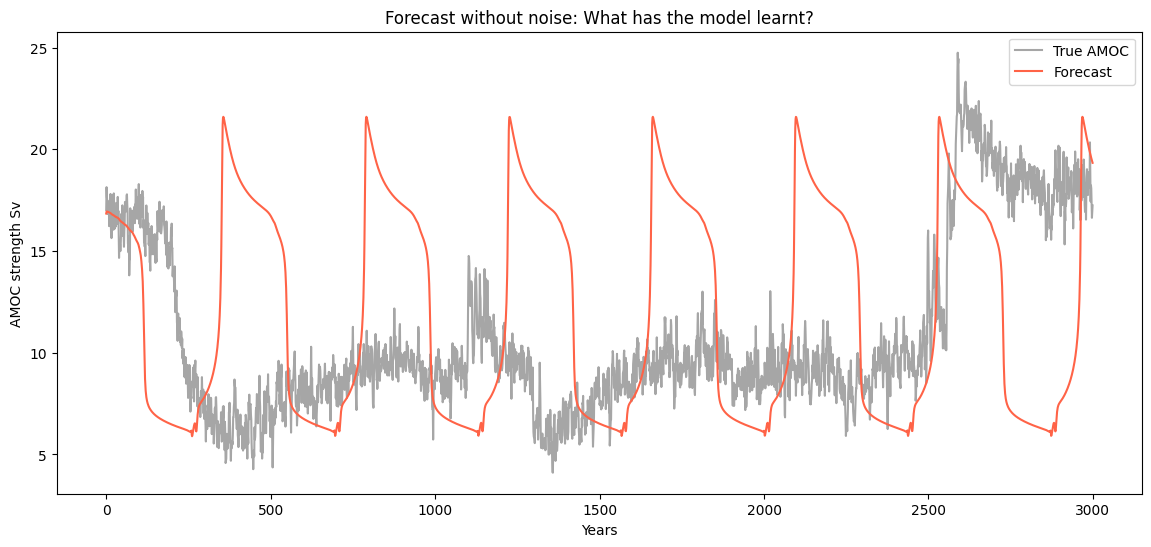

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X['AMOC'][start_idx:start_idx+steps], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, predictions['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast without noise: What has the model learnt?')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
#plt.savefig('Coupled_V1_no_noise.png')
plt.legend()

In [11]:
import sys
sys.path.append('..')  

import torch
import pickle
from CoupledModel import CoupledModel, _reconstruct_model

def load_v1_weights(pth_path, pkl_path):
    data = torch.load(pth_path, weights_only=False)
    model = _reconstruct_model(data['config'], data['state_dict'])
    with open(pkl_path, 'rb') as f:
        scalers = pickle.load(f)
    return {'model': model, 'x_scaler': scalers['x_scaler'], 'y_scaler': scalers['y_scaler']}

v1 = '../../GRU_coupled_model'

trained_models = {
    'AMOC':    load_v1_weights(f'{v1}/amoc_model.pth',    f'{v1}/scalers_AMOC.pkl'),
    'SFWF':    load_v1_weights(f'{v1}/SFWF_model.pth',    f'{v1}/scalers_SFWF.pkl'),
    'PD_200m': load_v1_weights(f'{v1}/PD_200m_model.pth', f'{v1}/scalers_PD_200m.pkl'),
}

coupled_v1_weights = CoupledModel.from_trained(trained_models)


In [12]:
rho = 0.1
k = 0.0
lag = 100
horizon = 65
device = 'cpu'

start_idx = 6600
models = ['AMOC', 'SFWF', 'PD_200m']
features = {
    'AMOC': ['SFWF', 'PD_200m'],
    'SFWF': ['AMOC', 'PD_200m'],
    'PD_200m': ['SFWF', 'AMOC'],
}
steps = 3000
threshold = 13

predictions = coupled_v1_weights.predict(device, X, start_idx, lag, horizon, models, features, steps, threshold, rho, k)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


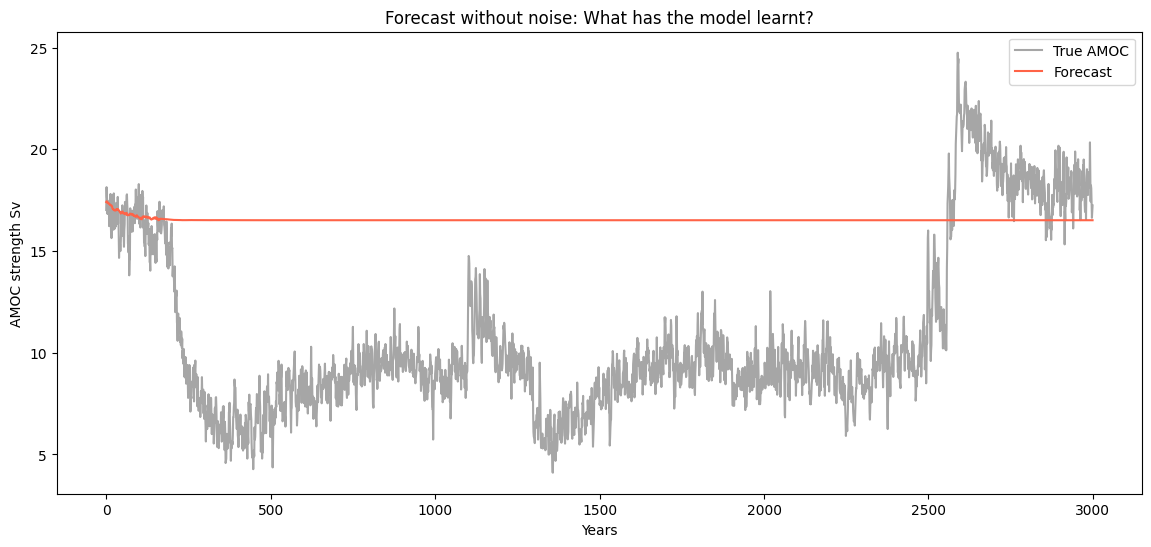

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X['AMOC'][start_idx:start_idx+steps], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, predictions['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast without noise: What has the model learnt?')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
#plt.savefig('Coupled_V1_no_noise.png')
plt.legend()